In [487]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [504]:
F = 96485 # C/mol
R = 8.314 # J/(mol * k)
T = 300 # K
n = 5
k0_1 = 3 # ms^-1
k0_2 = 1 # ms^-1
z_1 = 1
z_2 = 0
Ca_conc_cyto_0 = 0.1e-6 # M
#Ca_conc_e = 3e-6 # M
Ca_conc_e = 40e-3 # M
s_0 = 20
#P_Ca = .00001 # ms^-1
P_Ca = 10e-6 # m / s
#P_Ca = 4.3e-8 # ms^-1
V_0 = -70e-3 # V
V_neuron = 5.48e-11 # L
#V_neuron_L = V_neuron * 0.000000000000001 # L

In [505]:
def k_1(V):
    return k0_1 * np.exp(F * z_1 * V / R / T)

def k_2(V):
    return k0_2 * np.exp(F * z_2 * V / R / T)

def o_hat(V):
    return k_1(V) / (k_1(V)+k_2(V))

def current_to_molar_per_second(I, z):
    return -I / (z * F * V_neuron_L)

def i_ca(V, c_i, o):
    if np.abs(V) <= 0.00000001:
        i = P_Ca * 2 * F * 1e3 * (c_i - Ca_conc_e) # L'Hopital's
    else:
        i = P_Ca * 4 * (F / R) * (F / T) * 1e3 * V * (c_i - Ca_conc_e * np.exp(-2*F*V / (R * T))) / (1 - np.exp(-2*F*V / (R * T)))
    return i

def I_Ca(V, c_i, o):
    i = i_ca(V, c_i, o)
    return s_0 * i * o**n
    

def dodt(V, o):
    return k_1(V) * (1-o) -k_2(V) * o

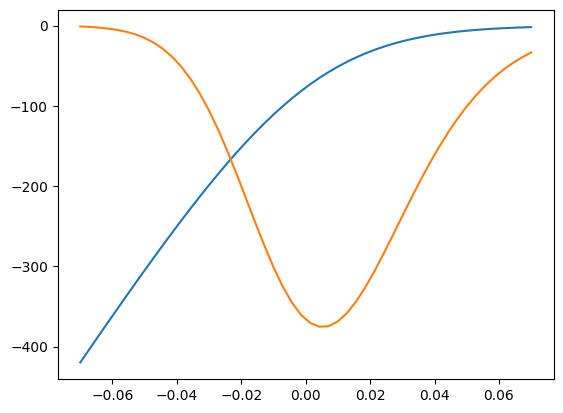

In [506]:
Vs = np.linspace(-.07,.07)
o_hats = list(map(lambda v: o_hat(v), Vs))
i_cs = list(map(lambda v: i_ca(v, Ca_conc_cyto_0, o_hat(v)), Vs))
I_Cas = list(map(lambda v: I_Ca(v, Ca_conc_cyto_0, o_hat(v)), Vs))
#plt.plot(Vs, o_hats)
plt.plot(Vs, i_cs)
plt.plot(Vs, I_Cas)
plt
();

In [491]:
I_Ca(0.001, Ca_conc_cyto_0, 0.7)

np.float64(-249.55160265376915)

In [497]:
# integrate
def dParams(t, params):
    V = params[0]
    o = params[1]
    
    return np.array([-I_Ca(V, Ca_conc_cyto_0, o), dodt(V, o)])
    #return np.array([0, dodt(V,o)])
    
#params_0 = np.array([V_0, o_hat(V_0)])
params_0 = np.array([-0.02, 0])
t_span = [0,3]
sol = solve_ivp(dParams, t_span, params_0)

[-0.00000000e+00 -2.36585568e-15 -3.62615712e-10 -2.33266553e-05
 -9.28443457e-05 -2.55399192e-04 -5.67326349e-04 -8.77157791e-04
 -1.22543355e-03 -1.60524299e-03 -1.88713300e-03 -1.60187140e-03
 -1.03427461e-03 -6.99074475e-04 -5.04321846e-04 -3.77418688e-04
 -3.02503583e-04 -2.56587772e-04 -2.21441493e-04 -1.99640268e-04
 -1.81147987e-04 -1.63960840e-04 -1.51883377e-04 -1.41154580e-04
 -1.31004809e-04 -1.22134718e-04 -1.15290390e-04 -1.09798394e-04
 -1.04537319e-04 -9.91226947e-05 -9.38196103e-05 -9.02214170e-05
 -8.67387601e-05 -8.29154195e-05 -7.89602821e-05 -7.64853180e-05
 -7.40194388e-05 -7.11661868e-05 -6.80620303e-05 -6.62523024e-05
 -6.44042912e-05 -6.21810776e-05 -5.96708120e-05 -5.82908041e-05
 -5.68501065e-05 -5.50641051e-05 -5.29879832e-05 -5.18988661e-05
 -5.07404611e-05 -4.92712384e-05 -4.75250467e-05 -4.66414910e-05
 -4.56872801e-05 -4.44557934e-05 -4.29672805e-05 -4.22340118e-05
 -4.14325672e-05 -4.03844979e-05 -3.91015667e-05 -3.84814736e-05
 -3.77975762e-05 -3.68942

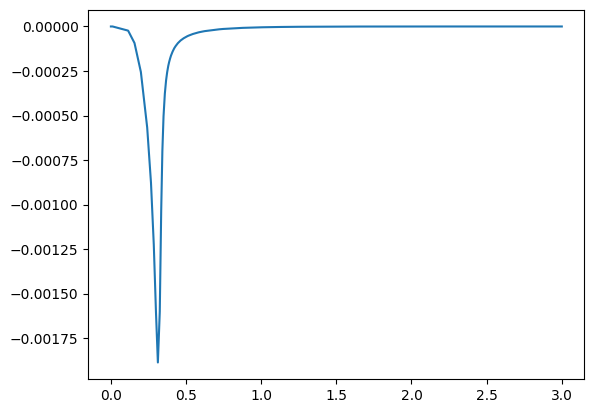

In [498]:
res = np.array(list(map(lambda x: I_Ca(x[0], Ca_conc_cyto_0, x[1])*10**-3, zip(sol.y[0], sol.y[1]))))
print(res)
plt.plot(sol.t, res)

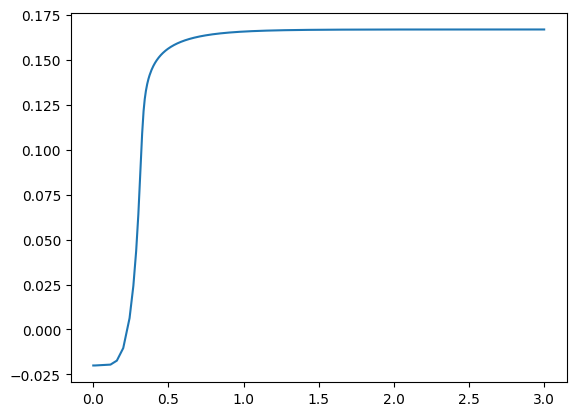

In [500]:
plt.plot(sol.t, sol.y[0])

In [252]:
Na_conc_out = .14 # M
Na_conc_in = .02 # M

def J_NCX(V):
    return Ca_conc_e * (Na_conc_out / Na_conc_in)**3 * np.exp(F * V / R / T)

In [253]:
# integrate
def dParams(t, params):
    V = params[0]
    o = params[1]
    Ca_conc = params[2]

    I_VGCC = I_Ca(V, Ca_conc, o)
    
    return np.array([-I_VGCC, dodt(V, o), current_to_molar_per_second(I_VGCC, 2)-J_NCX(V)])
    
params_0 = np.array([V_0, o_hat(V_0), Ca_conc_cyto_0])
t_span = [0,80]
sol = solve_ivp(dParams, t_span, params_0)

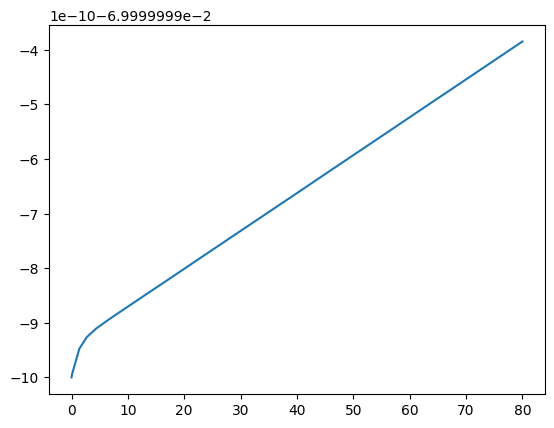

In [254]:
plt.plot(sol.t, sol.y[0])

In [255]:
J_NCX(-.07)

np.float64(6.86090441672261e-05)

In [256]:
current_to_molar_per_second(I_Ca(-0.07, Ca_conc_cyto_0, o_hat(-0.07)), 2)

np.float64(0.0006043857818132659)

In [257]:
V_neuron_L

5.236000000000001e-13

In [258]:
sol.y[0]

array([-0.07, -0.07, -0.07, -0.07, -0.07, -0.07, -0.07, -0.07, -0.07,
       -0.07, -0.07, -0.07, -0.07, -0.07, -0.07, -0.07, -0.07, -0.07,
       -0.07, -0.07, -0.07, -0.07, -0.07, -0.07, -0.07, -0.07, -0.07,
       -0.07])

In [259]:
V_neuron

5.48e-11

In [464]:
10e3

10000.0